# Đánh giá model HỆ SỐ NHÂN — so sánh 3 thuật toán

Nạp lại dự đoán đã lưu từ `train/train_heso.ipynb` (`pred_heso.parquet`).

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.color":"#ECECEC","font.size":10})
pd.set_option("display.width", 220)
BLUE, ORANGE, GREEN = "#0072B2", "#E69F00", "#009E73"

def metrics(y,p):
    y,p=np.asarray(y),np.asarray(p)
    return dict(MAE=mean_absolute_error(y,p), RMSE=mean_squared_error(y,p)**.5,
                R2=r2_score(y,p), MAPE=np.mean(np.abs((y-p)/y))*100)

PRED = Path("pred_heso.parquet")
assert PRED.exists(), "Chua co file du doan -> chay train/train_heso.ipynb truoc!"
df = pd.read_parquet(PRED)
ALGOS = sorted(df.algo.unique())
thangs = sorted(df.evaluation_month.unique())
print(f"Nap {len(df):,} dong du doan | thuat toan: {ALGOS} | thang: {thangs}")

Nap 2,593,080 dong du doan | thuat toan: ['HistGB', 'LightGBM', 'XGBoost'] | thang: ['2026-01', '2026-02', '2026-03']


**1. Bảng chỉ số — tổng gộp & từng test-set nhỏ theo tháng**

In [2]:
TARGET = "target_shown_multiplier"
rows = []
for algo in ALGOS:
    d = df[df.algo==algo]
    rows.append({"Thuat toan": algo, "Test-set": "TAT CA", "n": len(d), **metrics(d[TARGET], d.pred)})
    for th in thangs:
        dt = d[d.evaluation_month==th]
        rows.append({"Thuat toan": algo, "Test-set": th, "n": len(dt), **metrics(dt[TARGET], dt.pred)})
bang = pd.DataFrame(rows).round(4)
print("TONG GOP:"); display(bang[bang["Test-set"]=="TAT CA"].sort_values("MAE"))
print("\nTUNG TEST-SET NHO THEO THANG:"); display(bang[bang["Test-set"]!="TAT CA"])

TONG GOP:


,Thuat toan,Test-set,n,MAE,RMSE,R2,MAPE
0,HistGB,TAT CA,864360,0.0233,0.0362,0.9606,1.9121
8,XGBoost,TAT CA,864360,0.0234,0.0363,0.9603,1.9160
4,LightGBM,TAT CA,864360,0.0235,0.0367,0.9596,1.9230



TUNG TEST-SET NHO THEO THANG:


,Thuat toan,Test-set,n,MAE,RMSE,R2,MAPE
1,HistGB,2026-01,315360,0.0229,0.0350,0.9617,1.9078
2,HistGB,2026-02,234632,0.0234,0.0374,0.9590,1.9192
3,HistGB,2026-03,314368,0.0238,0.0365,0.9601,1.9112
5,LightGBM,2026-01,315360,0.0231,0.0355,0.9606,1.9245
6,LightGBM,2026-02,234632,0.0233,0.0373,0.9594,1.9107
7,LightGBM,2026-03,314368,0.0241,0.0374,0.9582,1.9306
9,XGBoost,2026-01,315360,0.0230,0.0351,0.9614,1.9167
10,XGBoost,2026-02,234632,0.0235,0.0375,0.9588,1.9228
11,XGBoost,2026-03,314368,0.0238,0.0366,0.9598,1.9103


**2. So với baseline + ROC-AUC phân biệt có surge**

In [3]:
from sklearn.metrics import roc_auc_score
for algo in ALGOS:
    d = df[df.algo==algo]
    per = metrics(d[TARGET], d["latest_observed_multiplier"])["MAE"]
    mae = metrics(d[TARGET], d.pred)["MAE"]
    auc = roc_auc_score((d[TARGET]>1).astype(int), d.pred)
    print(f"{algo:10} MAE model={mae:.4f}  MAE persistence={per:.4f}  ROC-AUC(co surge)={auc:.4f}")

HistGB     MAE model=0.0233  MAE persistence=0.0371  ROC-AUC(co surge)=0.9979


LightGBM   MAE model=0.0235  MAE persistence=0.0371  ROC-AUC(co surge)=0.9979


XGBoost    MAE model=0.0234  MAE persistence=0.0371  ROC-AUC(co surge)=0.9979


**3. Biểu đồ — cả 3 thuật toán**

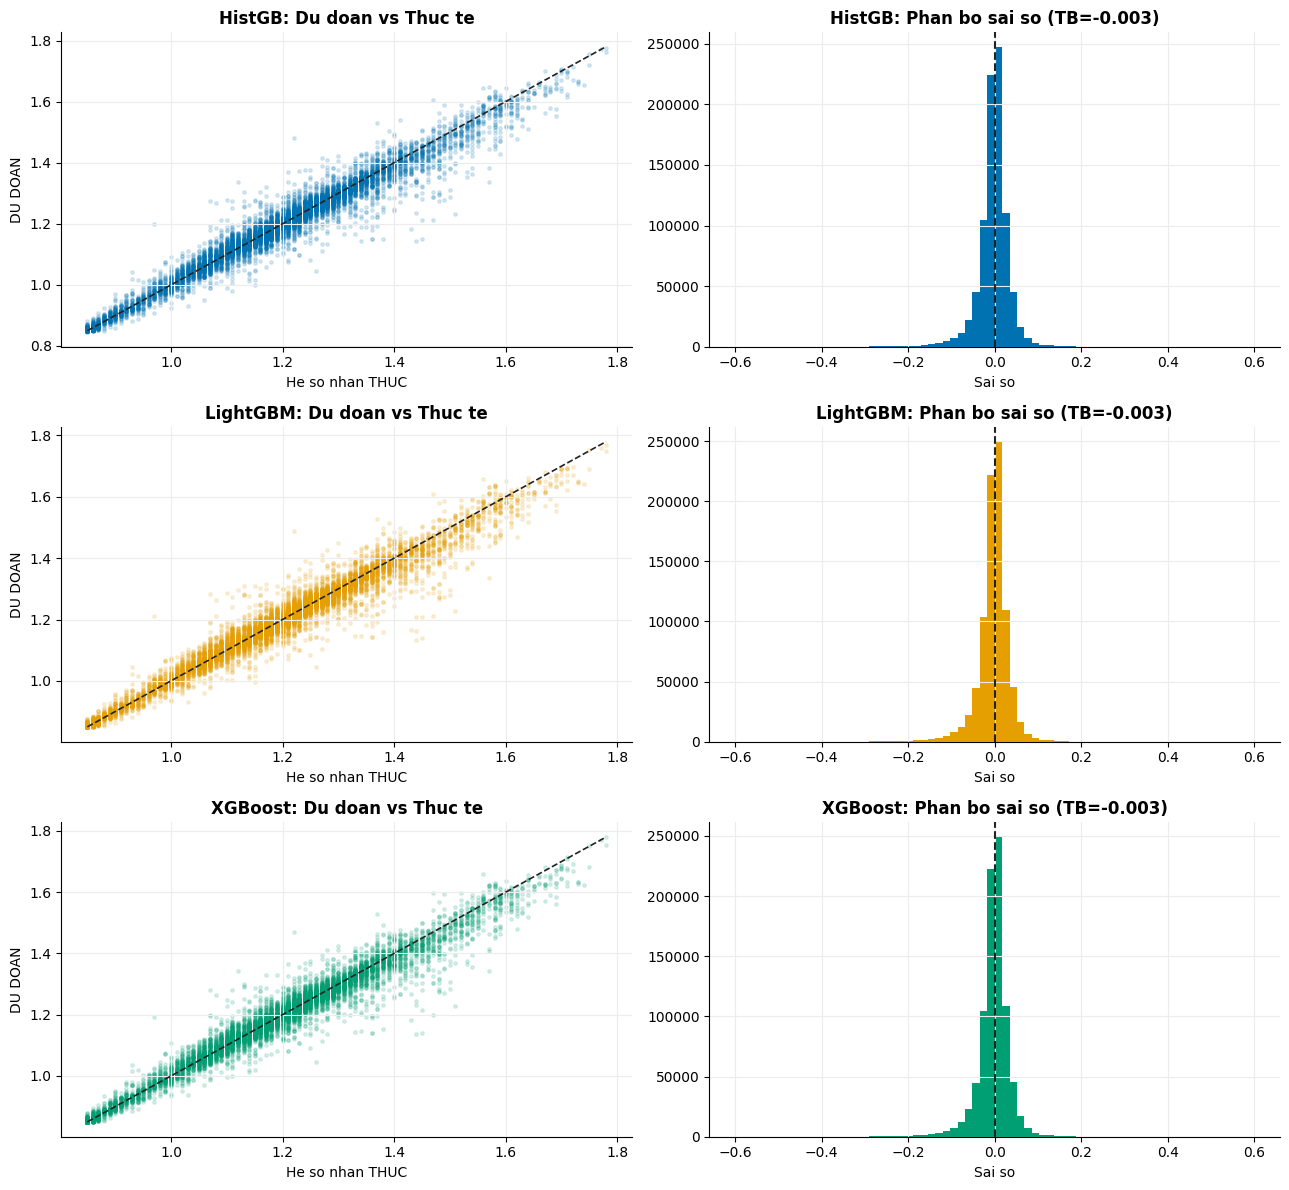

In [4]:
COLORS = dict(zip(ALGOS, [BLUE, ORANGE, GREEN]))
fig, ax = plt.subplots(len(ALGOS), 2, figsize=(13, 4*len(ALGOS)))
if len(ALGOS) == 1: ax = ax[None, :]
for i, algo in enumerate(ALGOS):
    d = df[df.algo==algo]
    c = COLORS[algo]
    s = d.sample(min(8000, len(d)), random_state=0)
    ax[i,0].scatter(s[TARGET], s.pred, s=6, alpha=.15, color=c)
    lim=[s[TARGET].min(),s[TARGET].max()]; ax[i,0].plot(lim,lim,"--",color="#222",lw=1.2)
    ax[i,0].set_xlabel("He so nhan THUC"); ax[i,0].set_ylabel("DU DOAN")
    ax[i,0].set_title(f"{algo}: Du doan vs Thuc te", fontweight="bold")

    err=d.pred-d[TARGET]
    ax[i,1].hist(err, bins=70, range=(-.6,.6), color=c); ax[i,1].axvline(0,color="#222",ls="--")
    ax[i,1].set_xlabel("Sai so")
    ax[i,1].set_title(f"{algo}: Phan bo sai so (TB={err.mean():+.3f})", fontweight="bold")
plt.tight_layout(); plt.show()

**4. So sánh MAE giữa 3 thuật toán (biểu đồ)**

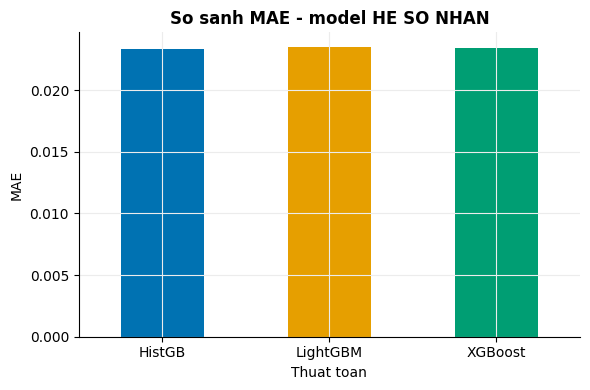

In [5]:
bt = bang[bang["Test-set"]=="TAT CA"].set_index("Thuat toan")["MAE"]
fig, ax = plt.subplots(figsize=(6,4))
bt.plot(kind="bar", ax=ax, color=[BLUE,ORANGE,GREEN][:len(bt)])
ax.set_ylabel("MAE"); ax.set_title("So sanh MAE - model HE SO NHAN", fontweight="bold"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**5. Test case thực tế — chênh lệch thực vs dự đoán**

Lấy 8 chuyến có surge + 7 chuyến không surge từ tập test, so **hệ số nhân thực** với **dự đoán của
cả 3 thuật toán** trên cùng chuyến (căn theo vị trí — cùng tập test, cùng thứ tự).

In [6]:
d0 = df[df.algo==ALGOS[0]].reset_index(drop=True)
co = d0[d0[TARGET]>1.1].sample(8, random_state=7).index
khong = d0[d0[TARGET]<=1.0].sample(7, random_state=7).index
pos = pd.Index(list(co) + list(khong))

case = pd.DataFrame({
    "Test-set": d0.loc[pos, "evaluation_month"].values,
    "HE SO THUC": d0.loc[pos, TARGET].round(2).values,
})
for algo in ALGOS:
    da = df[df.algo==algo].reset_index(drop=True)
    pred_v = da.loc[pos, "pred"].round(2).values
    err = (da.loc[pos, "pred"]-da.loc[pos, TARGET]).round(3).values
    case[f"{algo} DUDOAN"] = pred_v
    case[f"{algo} Sai so"] = err

print("15 TEST CASE THUC TE (8 co surge + 7 khong surge, ca 3 thuat toan):")
display(case.reset_index(drop=True))

15 TEST CASE THUC TE (8 co surge + 7 khong surge, ca 3 thuat toan):


,Test-set,HE SO THUC,HistGB DUDOAN,HistGB Sai so,LightGBM DUDOAN,LightGBM Sai so,XGBoost DUDOAN,XGBoost Sai so
0,2026-01,1.22,1.23,0.007,1.22,0.004,1.23,0.008
1,2026-03,1.18,1.18,0.005,1.18,0.003,1.18,0.003
2,2026-02,1.11,1.08,-0.034,1.07,-0.036,1.07,-0.041
3,2026-03,1.32,1.34,0.017,1.32,0.004,1.33,0.006
4,2026-01,1.29,1.28,-0.008,1.28,-0.014,1.27,-0.018
5,2026-03,1.29,1.27,-0.021,1.27,-0.023,1.27,-0.020
6,2026-02,1.57,1.57,0.001,1.56,-0.013,1.57,-0.001
7,2026-03,1.30,1.31,0.005,1.31,0.006,1.31,0.013
8,2026-02,0.95,0.97,0.020,0.96,0.006,0.95,0.001
9,2026-01,0.91,0.92,0.006,0.92,0.008,0.92,0.010
